In [1]:
def give_me_df(ticker):
    import yfinance as yf
    stock = yf.Ticker(ticker)
    df = stock.history(period='max')
    df[ticker] = df.Close.pct_change()
    return df[[ticker]].iloc[1:] 

In [2]:
df = give_me_df('FB')
df

,FB
Date,
2012-05-21,-0.109861
2012-05-22,-0.089039
2012-05-23,0.032258
2012-05-24,0.032188
2012-05-25,-0.033909
...,...
2020-09-30,0.000420
2020-10-01,0.018060
2020-10-02,-0.025091


In [3]:
dg = give_me_df('SPY')
dg

,SPY
Date,
1993-02-01,0.007285
1993-02-02,0.001903
1993-02-03,0.010638
1993-02-04,0.004135
1993-02-05,-0.000749
...,...
2020-09-30,0.007582
2020-10-01,0.006420
2020-10-02,-0.009494


In [4]:
dh = df.join(dg, how='inner')
dh

,FB,SPY
Date,,
2012-05-21,-0.109861,0.017262
2012-05-22,-0.089039,0.001706
2012-05-23,0.032258,0.000538
2012-05-24,0.032188,0.001971
2012-05-25,-0.033909,-0.003219
...,...,...
2020-09-30,0.000420,0.007582
2020-10-01,0.018060,0.006420
2020-10-02,-0.025091,-0.009494


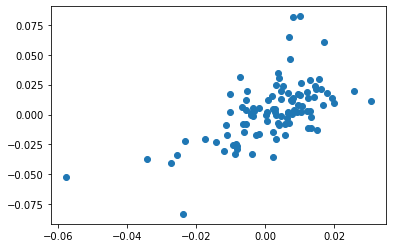

In [5]:
import matplotlib.pyplot as plt
plt.plot(dh.SPY[-100:], dh.FB[-100:], 'o')
plt.show()

In [8]:
x_train, y_train = dh.SPY[-200:-100].values.reshape((-1,1)), dh.FB[-200:-100].values
x_test, y_test = dh.SPY[-100:].values.reshape((-1,1)), dh.FB[-100:].values

In [9]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(100, 1) (100,)
(100, 1) (100,)


In [31]:
from sklearn.linear_model import LinearRegression
a = LinearRegression() # 리니너 리그레션 오브젝트(인스탄스) 생성 

In [11]:
print(dir(a))

['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_decision_function', '_estimator_type', '_get_param_names', '_get_tags', '_more_tags', '_preprocess_data', '_set_intercept', 'copy_X', 'fit', 'fit_intercept', 'get_params', 'n_jobs', 'normalize', 'predict', 'score', 'set_params']


In [24]:
a.fit(x_train, y_train) # 모델 트레인

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [25]:
y_train_pred = a.predict(x_train) # pred

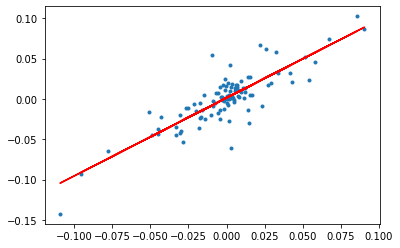

In [28]:
import matplotlib.pyplot as plt
plt.plot(x_train.reshape((-1,)), y_train, '.')
plt.plot(x_train.reshape((-1,)), y_train_pred, '-r')
plt.show()

In [29]:
y_test_pred = a.predict(x_test) # pred

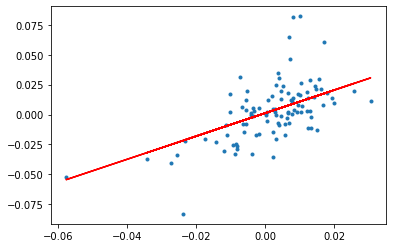

In [30]:
import matplotlib.pyplot as plt
plt.plot(x_test.reshape((-1,)), y_test, '.')
plt.plot(x_test.reshape((-1,)), y_test_pred, '-r')
plt.show()

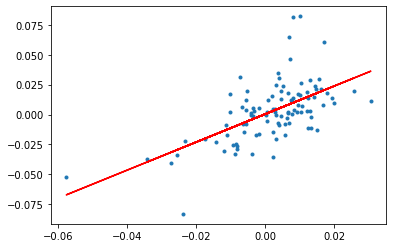

In [32]:
from sklearn.linear_model import LinearRegression
a = LinearRegression() 
a.fit(x_test, y_test)
y_test_pred = a.predict(x_test)

import matplotlib.pyplot as plt
plt.plot(x_test.reshape((-1,)), y_test, '.')
plt.plot(x_test.reshape((-1,)), y_test_pred, '-r')
plt.show()

In [33]:
a.coef_ # 직선의 기울기

array([1.17367844])

In [34]:
a.intercept_ # y 절편

0.00045396652024215414

In [35]:
df_1 = give_me_df('SPY')
df_2 = give_me_df('AAPL')
df_3 = give_me_df('FB')
dh = df_1.join(df_2, how='inner').join(df_3, how='inner')
dh

,SPY,AAPL,FB
Date,,,
2012-05-21,0.017262,0.058033,-0.109861
2012-05-22,0.001706,-0.007506,-0.089039
2012-05-23,0.000538,0.024433,0.032258
2012-05-24,0.001971,-0.009086,0.032188
2012-05-25,-0.003219,-0.005731,-0.033909
...,...,...,...
2020-09-30,0.007582,0.015076,0.000420
2020-10-01,0.006420,0.008462,0.018060
2020-10-02,-0.009494,-0.032280,-0.025091


In [36]:
x_train, y_train = dh[['SPY','AAPL']][-200:-100].values, dh.FB[-200:-100].values
x_test, y_test = dh[['SPY','AAPL']][-100:].values, dh.FB[-100:].values

In [37]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(100, 2) (100,)
(100, 2) (100,)


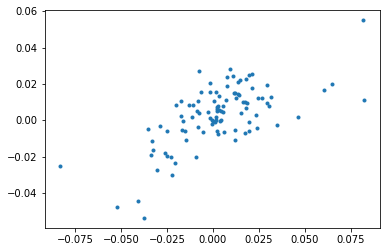

In [38]:
from sklearn.linear_model import LinearRegression
a = LinearRegression() 
a.fit(x_train, y_train)
y_test_pred = a.predict(x_test)

import matplotlib.pyplot as plt
plt.plot(y_test, y_test_pred, '.')
plt.show()

In [39]:
a.coef_ # 직선의 기울기

array([0.41434653, 0.49380303])

In [40]:
a.intercept_ # y 절편

3.9733622290601665e-05